# Практикум по программированию на языке Python

## <font color='lilac'>Методы повышения эффективности кода</font>

#### Роман Ищенко (roman.ischenko@gmail.com)
#### Москва, 2025

In [8]:
import warnings
warnings.filterwarnings('ignore')

### <font color='lilac'>Производительность Python</font>

- Быстродействие кода на Python существенно уступает коду, написанному на компилируемых языках<br><br>
- Но Python очень удобен и популярен, поэтому сделано много попыток его ускорения<br><br>
- Популярен подход с написанием основного кода на C/C++/CUDA и предоставлением пользователю удобного интерфейса к нему в Python (numpy, pycuda, библиотеки для глубинного обучения)<br><br>
- Однако часто хочется получать эффективный код прямо в Python

### <font color='lilac'>Возможные методы повышения производительности</font>

- Многопоточность и многопроцессорность
- Альтернативные реализации Python: Pypy, Jython, Iron Python
- Библиотека Numba
- Расширение Cython

### <font color='lilac'>Процесс и поток</font>

- __Процесс__ - это единица приложения, работающая в операционной системе, имеет собственную изолированную память
- __Поток__ - вычислительная единица внутри процесса, работает в памяти процесса, имеет собственный код для выполнения<br><br>
- В процессе может быть >= 1 потока
- Одно ядро процессора в моменте времени может выполнять код одного потока
- Если потоков много, а ядро одно, то оно будет переключаться между ними, создавая иллюзию параллельности для пользователя
- Если и потоков, и ядер много, то потоки могут действительно выполняться параллельно
- Аналогичным образом работает параллелизм между процессами

### <font color='lilac'>Мотивация</font>

Рассмотрим простенький пример с обкачкой статей Хабра, однако не будем это делать в лоб

In [9]:
import requests
import time 

from bs4 import BeautifulSoup # удобная библиотека для парсинга html
from multiprocessing.dummy import Pool as ThreadPool

In [10]:
base_url = "https://habr.com/ru/articles/"

def get_page(url, n_attempts=5, t_sleep=1, headers={}, **kwargs):
    for i in range(n_attempts):
        page = requests.get(url, headers=headers)
        if page.status_code == 200:
            return page
        time.sleep(t_sleep)
    print("DEBUG: url doesn't load", url)
    return None

def get_habr_artical(artical_number):
    
    page = get_page(f"{base_url}{artical_number}")
    if page:
        return page.content
    return None

In [11]:
%%time

page = get_page(f"{base_url}{1}")

CPU times: user 17.3 ms, sys: 13.6 ms, total: 30.9 ms
Wall time: 852 ms


In [12]:
%%time
N = 10
pages = []
for i in range(1, N):
    pages.append(get_habr_artical(i))

DEBUG: url doesn't load https://habr.com/ru/articles/3
DEBUG: url doesn't load https://habr.com/ru/articles/5
CPU times: user 316 ms, sys: 63.6 ms, total: 379 ms
Wall time: 17.4 s


In [13]:
%%time
N = 10

with ThreadPool(3) as pool:
    pages = pool.map(get_habr_artical, range(1, N))

DEBUG: url doesn't load https://habr.com/ru/articles/3
DEBUG: url doesn't load https://habr.com/ru/articles/5
CPU times: user 283 ms, sys: 52.1 ms, total: 335 ms
Wall time: 6.26 s


In [14]:
pages[0]

b'<!DOCTYPE html>\n<html lang="ru">\n\n  <head>\n    <title>Wiki-FAQ \xd0\xb4\xd0\xbb\xd1\x8f \xd0\xa5\xd0\xb0\xd0\xb1\xd1\x80\xd0\xb0\xd1\x85\xd0\xb0\xd0\xb1\xd1\x80\xd0\xb0 &#x2F; \xd0\xa5\xd0\xb0\xd0\xb1\xd1\x80</title>\n<meta property="fb:app_id" content="444736788986613">\n<meta property="fb:pages" content="472597926099084">\n<meta name="twitter:card" content="summary_large_image">\n<meta name="twitter:site" content="@habr_com">\n<meta property="og:site_name" content="\xd0\xa5\xd0\xb0\xd0\xb1\xd1\x80">\n<link href="https://habr.com/ru/rss/post/1/?fl=ru" type="application/rss+xml" title rel="alternate" name="rss">\n<link href="https://habr.com/ru/articles/1/" rel="canonical" data-hid="e3fa780">\n<link rel="image_src" href="https://habr.com/share/publication/1/5f946dfec41a62041bf9eccde651cf32/" data-hid="2a79c45">\n<link rel="amphtml" href="https://habr.com/ru/amp/publications/1/">\n<meta property="og:title" content="Wiki-FAQ \xd0\xb4\xd0\xbb\xd1\x8f \xd0\xa5\xd0\xb0\xd0\xb1\xd1\x80

In [15]:
soups = [BeautifulSoup(page, 'lxml') for page in pages if page]
titles = [soup.title.text for soup in soups]

len(titles), titles

(7,
 ['Wiki-FAQ для Хабрахабра / Хабр',
  'Мы знаем много недоделок на сайте… но! / Хабр',
  'Маслов, Сокур и партнеры пиарят Google в России / Хабр',
  'Подкасты на Хабрахабре / Хабр',
  'Самопроизвольное разлогинивание / Хабр',
  'Неожиданная популярность ресурсов среди региональных аудиторий / Хабр',
  'А нужно ли удаление? / Хабр'])

In [17]:
a = BeautifulSoup(pages[0], 'lxml')
a.body.div.div.div

<div class="tm-layout__wrapper"><!--[--><!-- --><div></div><div class="header-banner-wrapper"><div class="element-wrapper above-header" style="--754c4550:100%;--56cb6579:auto;"><!--[--><div class="placeholder-wrapper banner-container__placeholder"><!-- --><!-- --><!-- --><!-- --><!-- --><!-- --><!-- --><!-- --><!-- --><!-- --><!-- --><!-- --><!-- --><!-- --><!-- --><!-- --><!-- --><!-- --><!-- --><!-- --><!-- --><!-- --><!-- --><!-- --><!-- --><!-- --><!-- --><!-- --><!-- --><!-- --><!-- --><!-- --><!-- --><div class="adfox-banner-placeholder above-header" data-v-24012b5e=""><div class="image loads" data-v-24012b5e=""></div><div class="lines" data-v-24012b5e=""><div class="line loads" data-v-24012b5e=""></div><div class="line loads" data-v-24012b5e=""></div><div class="line loads" data-v-24012b5e=""></div></div></div><!-- --><!-- --><!-- --></div><!--[--><div class="banner-target" id="adfox_175449164307199013"></div><!--]--><!--]--></div></div><header class="tm-header tm-header" data-t

### <font color='lilac'>Создание потока в Python</font>

- Для работы с потоками в Python есть стандартный модуль threading
- Основным классом является `Thread` (поток)

In [18]:
import threading

Функциональное создание потока:

In [19]:
def thread_function(x):
    print(get_habr_artical(x))

thread = threading.Thread(target=thread_function, args=(10, ))
thread.start()

# thread.start()  # RuntimeError: threads can only be started once

b'<!DOCTYPE html>\n<html lang="ru">\n\n  <head>\n    <title>\xd0\x9f\xd0\xbe\xd0\xbc\xd0\xb5\xd1\x82\xd0\xba\xd0\xb8 \xd1\x83 \xd0\xbd\xd0\xbe\xd0\xb2\xd1\x8b\xd1\x85 \xd0\xba\xd0\xbe\xd0\xbc\xd0\xbc\xd0\xb5\xd0\xbd\xd1\x82\xd0\xb0\xd1\x80\xd0\xb8\xd0\xb5\xd0\xb2 &#x2F; \xd0\xa5\xd0\xb0\xd0\xb1\xd1\x80</title>\n<meta property="fb:app_id" content="444736788986613">\n<meta property="fb:pages" content="472597926099084">\n<meta name="twitter:card" content="summary_large_image">\n<meta name="twitter:site" content="@habr_com">\n<meta property="og:site_name" content="\xd0\xa5\xd0\xb0\xd0\xb1\xd1\x80">\n<link href="https://habr.com/ru/rss/post/10/?fl=ru" type="application/rss+xml" title rel="alternate" name="rss">\n<link href="https://habr.com/ru/articles/10/" rel="canonical" data-hid="e3fa780">\n<link rel="image_src" href="https://habr.com/share/publication/10/25fa58c7cfdb50625e77b1fd423462cf/" data-hid="2a79c45">\n<link rel="amphtml" href="https://habr.com/ru/amp/publications/10/">\n<meta pr

- Потоку передается функция, которую он должен выполнить, и аргументы
- После запуска `start` он будет выполняться до выхода из функции или ошибки
- Запустить его второй раз не получится (RuntimeError)

### <font color='lilac'>Создание потока в Python</font>

- Поток также можно описать в виде класс-наследника `Thread`
- Класс должен определять метод `run`

In [21]:
class MyThread(threading.Thread):
    def __init__(self, x):
        threading.Thread.__init__(self)
        self.x = x
        self.content = 'Not yet'

    def thread_function(self):
        self.content = get_habr_artical(self.x)

    def run(self):
        self.thread_function()

print_thread = MyThread(x=10)
print_thread.start()
print_thread.join()
print(print_thread.content)

# print_thread.start()  # RuntimeError: threads can only be started once

b'<!DOCTYPE html>\n<html lang="ru">\n\n  <head>\n    <title>\xd0\x9f\xd0\xbe\xd0\xbc\xd0\xb5\xd1\x82\xd0\xba\xd0\xb8 \xd1\x83 \xd0\xbd\xd0\xbe\xd0\xb2\xd1\x8b\xd1\x85 \xd0\xba\xd0\xbe\xd0\xbc\xd0\xbc\xd0\xb5\xd0\xbd\xd1\x82\xd0\xb0\xd1\x80\xd0\xb8\xd0\xb5\xd0\xb2 &#x2F; \xd0\xa5\xd0\xb0\xd0\xb1\xd1\x80</title>\n<meta property="fb:app_id" content="444736788986613">\n<meta property="fb:pages" content="472597926099084">\n<meta name="twitter:card" content="summary_large_image">\n<meta name="twitter:site" content="@habr_com">\n<meta property="og:site_name" content="\xd0\xa5\xd0\xb0\xd0\xb1\xd1\x80">\n<link href="https://habr.com/ru/rss/post/10/?fl=ru" type="application/rss+xml" title rel="alternate" name="rss">\n<link href="https://habr.com/ru/articles/10/" rel="canonical" data-hid="e3fa780">\n<link rel="image_src" href="https://habr.com/share/publication/10/25fa58c7cfdb50625e77b1fd423462cf/" data-hid="2a79c45">\n<link rel="amphtml" href="https://habr.com/ru/amp/publications/10/">\n<meta pr

### <font color='lilac'>Потоки-демоны</font>

- Потоки могут выполняться в обычном и фоновом (daemon) режимах
- Потоки-демоны используются для выполнения фоновых задач (отправка ping-ов, очистка мусора), они имеют смысл только в процессе существования основного потока
- При своем завершении процесс будет дожидаться окончания работы обычных потоков
- Потоки-демоны будут автоматически уничтожены при завершении процесса
- Такие потоки можно создавать и дальше за ними не следить, обычные же потоки нужно явно завершать<br><br>

Создание потока в режиме демона:

In [22]:
from threading import Thread
import time

In [ ]:
def show_timer():
    count = 0
    while True:
        count += 1
        time.sleep(1)
        print(f'Ждём {count} секунд...', end='\r')


# t = Thread(target=show_timer)
t = Thread(target=show_timer, daemon=True)
t.start()

answer = input('Press any key for exit\n')
print('Done')

### <font color='lilac'>Основные методы и атрибуты класса Thread</font>

Методы:

- `start` - запуск потока
- `run` - выполняет код потока
- `join` - блокирует вызывающий поток до завершения потока, у которого вызван `join`
- `is_alive` - возвращает флаг незавершенности потока

Атрибуты:
- `name` - имя потока
- `daemon` - флаг потоком фоновый или обычный
- `ident` - идентификатор потока, пока не вызван `start` он `None`.

### <font color='lilac'>Пример запуска потока</font>

In [23]:
import time

def wait(s):
    print('wait started')
    time.sleep(s)
    print('wait finished')

thread = threading.Thread(target=wait, args=(2, ), name='Wait Thread')
print('Is alive: ', thread.is_alive())
print('Thread identificator: ', thread.ident)
thread.start()

print('Is alive: ', thread.is_alive())
print('Is daemon: ', thread.daemon)
print('Thread name: ', thread.name)
print('Thread identificator: ', thread.ident)
thread.join()
print('Is alive: ', thread.is_alive())
print('Thread identificator: ', thread.ident)


Is alive:  False
Thread identificator:  None
wait started
Is alive:  True
Is daemon:  False
Thread name:  Wait Thread
Thread identificator:  6292271104
wait finished
Is alive:  False
Thread identificator:  6292271104


### <font color='lilac'>Доступ к разделяемым ресурсам</font>

- Потоки не имеют своей памяти и все работают с одной памятью родительского процесса
- Порядок выполнения потоков недетерминирован, в многопоточной среде несколько потоков могут одновременно получить доступ к одному ресурсу
- Без надлежащего контроля это может привести к ошибкам и падению процесса
- Потоки нельзя просто так останавливать извне, поэтому ограничения нужно наложить заранее, до запуска<br><br>

- Для контроля за доступом к ресурсам есть несколько инструментов:
    - Мьютекс (Mutex, Lock)
    - Рекурсивный мьютекс (RLock)
    - Семафор (Semaphore)
    - Событие (Event)
    - Условная переменная (Condition variable)
    - Барьер (Barrier)

### <font color='lilac'>Простая блокировка Lock</font>

- Mutex - это объект, который может в каждый момент времени быть занят не более чем одним потоком
- Все потоки проверяют его на занятость и, если он занят, ожидают освобождения

In [ ]:
mutex = threading.Lock()

def thread_safe_function():
    mutex.acquire()
    # Critical section
    mutex.release()

Для избежания взаимных блокировок (deadlocks) освобождение mutex нужно делать всегда, в т.ч. при ошибках и исключениях

### <font color='lilac'>Пример использования Mutex</font>

Сравним потокобезопасный и непотокобезопасный коды в задаче инкремента разделяемого ресурса ([источник](https://geekbrains.ru/posts/python_multithreading_pt2))

In [24]:
import threading
from random import random, shuffle
import time

In [25]:
protected_resource, unprotected_resource = 0, 0
mutex = threading.Lock()
NUM = 500
freq = NUM * 2


def inc(x):
    # Random processing time
    time.sleep(random() / freq)
    return x + 1


def dec(x):
    # Random processing time
    time.sleep(random() / freq)
    return x - 1


def safe_plus():
    global protected_resource
    for i in range(NUM):
        # Random external time
        time.sleep(random() / freq)
        with mutex:
            protected_resource = inc(protected_resource)


def safe_minus():
    global protected_resource
    for i in range(NUM):
        # Random external time
        time.sleep(random() / freq)
        with mutex:
            protected_resource = dec(protected_resource)


def risky_plus():
    global unprotected_resource
    for i in range(NUM):
        # Random external time
        time.sleep(random() / freq)
        unprotected_resource = inc(unprotected_resource)


def risky_minus():
    global unprotected_resource
    for i in range(NUM):
        # Random external time
        time.sleep(random() / freq)
        unprotected_resource = dec(unprotected_resource)

### <font color='lilac'>Пример использования Mutex</font>

- Race condition приводит к случайному результату: из-за неатомарности обновления часть операций теряется

In [38]:
targets = [safe_plus, safe_minus, risky_plus, risky_minus]
shuffle(targets)
threads = [threading.Thread(target=tg) for tg in targets]
for thrd in threads:
    thrd.start()

for thrd in threads:
    thrd.join()

print(f'Threadsafe result: {protected_resource}')
print(f'Non-threadsafe result: {unprotected_resource}')

Threadsafe result: 0
Non-threadsafe result: 88


### <font color='lilac'>Прочие инструменты контроля доступа</font>

- Рекурсивный мьютекс - такой же, как и обычный, но один поток может многократно входить в критическую секцию<br><br>
- Семафор - дает доступ к ресурсу заданному числу потоков<br><br>
- Событие - блокирует ресурс до выполнения некоторого условия, о котором уведовляет один из потоков<br><br>
- Условная переменная - обертка типа Event вокруг других блокировок для блокирования по определенным событиям<br><br>
- Барьер - создает точку синхронизации для заданного числа потоков, пока они все не дойдут до него, никто дальше не выполняется

In [ ]:
s = threading.Semaphore(4)

s.acquire()
s.release()


e = threading.Event()

e.wait()
e.is_set()
e.set()
e.clear()

### <font color='lilac'>Проблемы с многопоточностью в Python</font>

- Существует несколько реализаций Python, наиболее популярная (стандартная) - CPython
- Исторически CPython был реализован с глобальной блокировкой потоков Global Interpreter Lock (GIL)

Что такое GIL:
- GIL - это блокировка, которая не позволяет в каждый момент времени выполняться не более чем одному потоку
- Для этого через равные промежутки времени (100 тиков) интерпретатор усыпляет работающий поток и дает возможность поработать один промежуток какому-то иному потоку
- Остановка происходит даже в том случае, если поток всего один
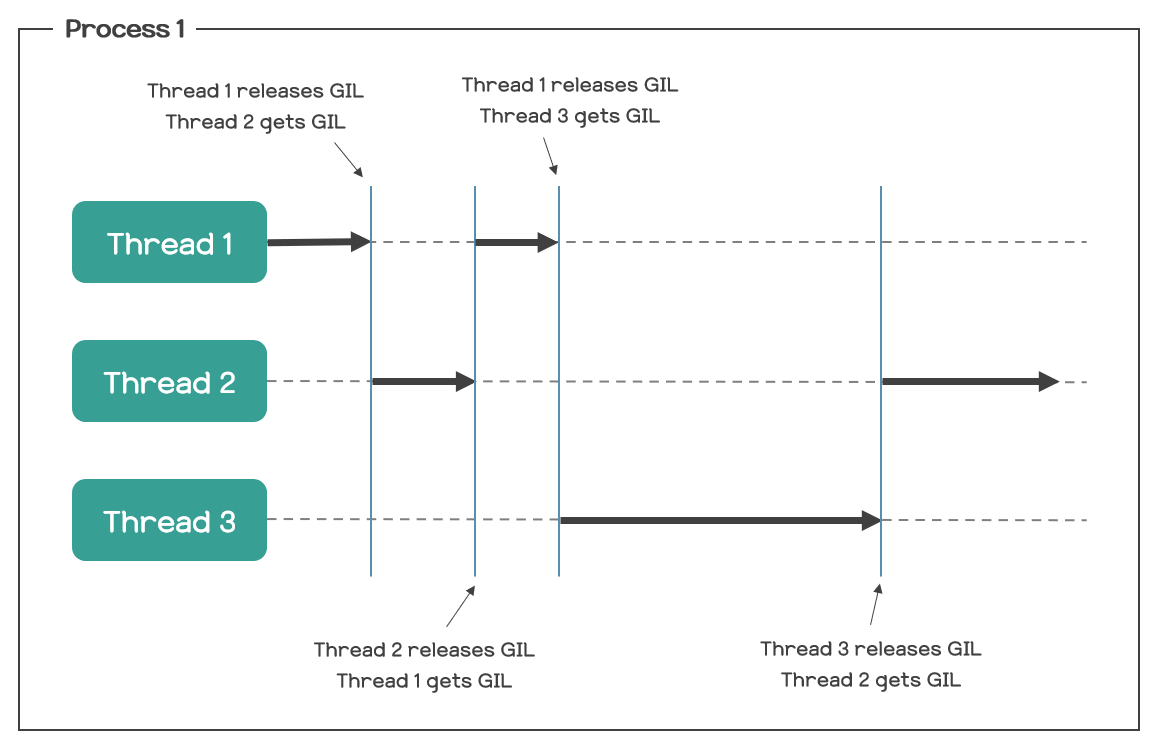


Зачем нужен GIL:
- Реализация менеджмента памяти и сборки мусора в CPython не является потокобезопасной
- Без него C-расширения языка, которые активно используются, не смогут нормально работать
- За счет отсутствия необходимости учета разных ссылок на объекты из разных потоков однопоточные приложения выполняются с GIL быстрее

Где еще есть GIL:
- В Jython и IronPython GIL нет
- В PyPy есть
- В Cython есть, но может выключаться на секцию кода

### <font color='lilac'>К чему приводит наличие GIL</font>

- Многопоточные приложения, ориентированные на использование вычислений на CPU (не I/O операций) не могут работать параллельно<br><br>
- Вычисления не только не становятся быстрее, но и сильно замедляются при увеличении числа потоков, поскольку каждое переключение требует большого числа системных вызовов<br><br>
- Замедление на многоядерном процессоре будет еще больше, чем на одноядерном, поскольку интерпретатор не синхронизирован с ОС (он хочет разместить все на одном ядре, а ОС пытается разложить потоки на разные ядра)<br><br>
- В интерпретаторе нет своего расписания очереди потоков, используется расписание ОС, это приводит к проблемам при обработке сигналов

### <font color='lilac'>Реакция на сигналы ОС</font>

- В Python сигналы могут обрабатываться только в главном потоке<br><br>
- При этом интерпретатор не может сам потребовать, чтобы на следующем промежутке включился главный поток<br><br>
- Он пытается переключать потоки с GIL не раз в 100 тиков, а каждый тик<br><br>
- В результате выполнение кода может замедлиться, и до перехода в главный поток Python не реагирует на сигналы<br><br>
- Помимо этого, внутри одного тика интерпретатор невозможно прервать<br><br>
- Тик длится не фиксированное время, а некоторый набор инструкций (по-умолчанию - 100 байткодов), в которые интерпретатор транслировал исходный код<br><br>

### <font color='lilac'>Пример проблем с GIL</font>

Однопоточный код:

In [41]:
def func(i):
    while i < 5e+7: i += 1

ts = time.time()
func(0)
print(f'Elapsed time: {round(time.time() - ts, 2)}')

Elapsed time: 1.15


Многопоточный код:

In [42]:
ts = time.time()
threads = []
for _ in range(2):
    thread = threading.Thread(target=func, args=(0, ))
    thread.start()
    threads.append(thread)

for thread in threads:
    thread.join()

print(f'Elapsed time: {round(time.time() - ts, 2)}')

Elapsed time: 2.3


### <font color='lilac'>Когда многопоточный код полезен</font>

- Независимые и не интенсивные I/O-операции с файлами, запросами или БД, логгирование<br><br>
    - время ожидание завершения работы системных вызовов, связанных с I/O-операциями относительно велико
    - поток, ожидающий этого, не меняет ничего в состоянии интерпретатора до выполнения следующего фрагмента кода
    - значит на это время он может освободить GIL и дать другому потоку продолжить выполнение<br><br>

- Отрисовка GUI

Пример с логгированием:

In [ ]:
flag = True
def print_message():
    while flag:
        time.sleep(1)
        print('I print this while func works')
    
log_thread = threading.Thread(target=print_message)
log_thread.start()
ts = time.time()
func(-5e+7)
print('Finished')
print(f'Elapsed time: {round(time.time() - ts, 2)}')
flag = False


### <font color='lilac'>Будущее GIL</font>

- Проблема с GIL действительно есть, однако её важность для большинства пользователей преувеличена
- Попытки избавиться от GIL предпринимались многократно, но часто проваливались из-за требования неухудшения производительности для однопоточных приложений
- Но есть и успешные перспективные примеры (https://github.com/colesbury/nogil)
- Одна из возможных альтернатив - механизм подинтерпретаторов (subinterpreters, версия Python 3.9+)
- Пробуются разные идеи, основанные на изменении методов подсчёта ссылок, аллокации памяти и принципов работы виртуальной машины

### <font color='lilac'>Многопроцессорный параллелизм</font>

- Процессы работают в собственных адресных пространствах и имеют каждый свои данные, в т.ч. и GIL в случае Python
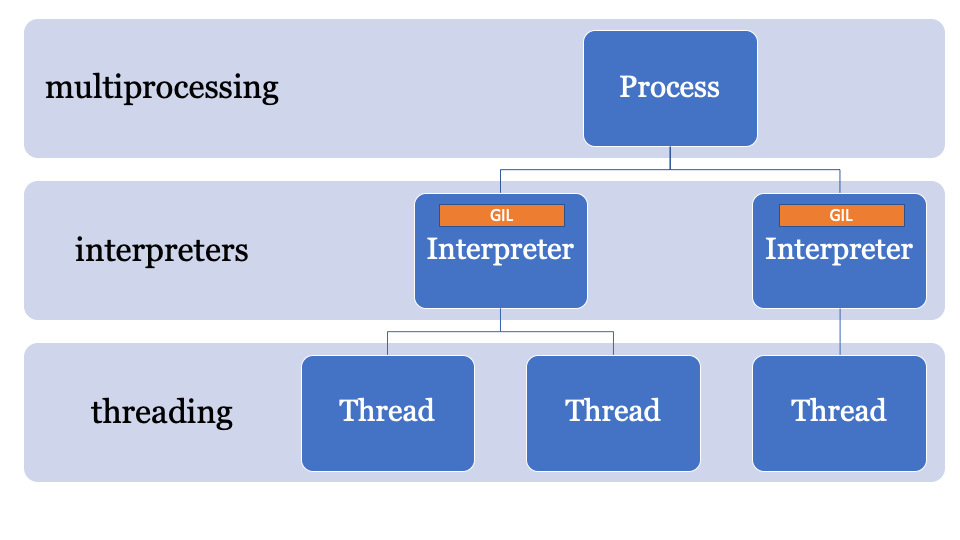

- Взаимодействие между ними можно организовать также, как и для любых других процессов: через файлы (в т.ч. вирутуальные) или обмен сообщениями (multiprocessing, MPI)<br><br>

- У каждого процесса есть `pid`, который можно получить вызовом `os.getpid()`
- Воспользуемся для примера модулем multiprocessing, все похоже на потоки:

In [43]:
import os
from multiprocessing import Process

def func(number):
    result = number ** 2
    print(f'func was called by process id {os.getpid()} with number {number}')

procs, numbers = [], [5, 10, 15, 20, 25]

if __name__ == '__main__':    
    for index, number in enumerate(numbers):
        proc = Process(target=func, args=(number,))
        procs.append(proc)
        proc.start()
        
    for proc in procs:
        proc.join()

Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "<string>", line 1, in <module>
    from multiprocessing.spawn import spawn_main; spawn_main(tracker_fd=82, pipe_handle=103)
                                                  ~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<string>", line 1, in <module>
    from multiprocessing.spawn import spawn_main; spawn_main(tracker_fd=82, pipe_handle=99)
                                                  ~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/rois/.pyenv/versions/3.13.5/lib/python3.13/multiprocessing/spawn.py", line 122, in spawn_main
    exitcode = _main(fd, parent_sentinel)
  File "/Users/rois/.pyenv/versions/3.13.5/lib/python3.13/multiprocessing/spawn.py", line 122, in spawn_main
    exitcode = _main(fd, parent_sentinel)
  File "/Users/rois/.pyenv/versions/3.13.5/lib/python3.13/multiprocessing/s

### <font color='lilac'>Блокировки для процессов</font>

- `multiprocessing.Lock` реализован как объект семафора в ОС вне памяти процесса, и каждый процесс может получить к нему доступ и изменять его

In [ ]:
from multiprocessing import Process, Lock

def func(lock, num):
    with lock:
        time.sleep(1)
        print(num)

lock = Lock()
procs = []

if __name__ == '__main__':
    for num in range(10):
        pr = Process(target=func, args=(lock, num))
        procs.append(pr)
        pr.start()

    for proc in procs:
        proc.join()


### <font color='lilac'>Совместный доступ к объектам</font>

- Передавать параметры по ссылке бессмысленно - они копируются и сериализуются для передачи в подпроцесс
- Тем не менее, можно пользоваться блоками разделяемой памяти в ОЗУ - `multiprocessing.shared_memory`
- Это относительно низкоуровневый подход, на его основе реализованы более удобные `Value` и `Array`:

In [ ]:
from multiprocessing import Value, Array

def func(number, array):
    number.value = 10
    for i in range(len(array)):
        array[i] = -array[i]

number = Value('d', 0.0)
array = Array('i', range(10))

p = Process(target=func, args=(number, array))
p.start()
p.join()

print(number.value)
print(array[:])

### <font color='lilac'>Pypy Python</font>

- Реализация интерпретатора Python, написанная на фреймворке RPython (синтаксис аналогичен Python)<br><br>
- Использует just-in-time (JIT) компиляцию:
    - при запуске код анализируется, наиболее часто используемые фрагменты (как циклы) переводятся в машинный код
    - в таком виде они оптимизируются
    - при выполнении исходные фрагменты заменяются на оптимизированные<br><br>
- В ряде случаев JIT позволяет в разы ускорить выполнение кода на Python, как правило, код должен выполняться длительное время<br><br>
- Цена использования JIT - более высокое потребление памяти в сложных и долго работающих процессах<br><br>
- PyPy поддерживает все конструкции соответствующей версии языка Python, но работает только с частью библиотек и C-расширений<br><br>
- JIT - не компиляция, т.е. получить на выходе исполняемый бинарный файл не получится

### <font color='lilac'>Библиотека Numba</font>

- Инструмент для компиляции части кода в LLVM, переводит часть кода на Python и NumPy в машинный код<br><br>
- Далее эти фрагменты кода выполняются на CPU (или GPU) минуя интерпретатор<br><br>
- Охватывает не весь язык, но может помочь в каких-то высоконагруженных секциях кода, скорость получается сопоставимой с реализацией на C/C++<br><br>
- Numba использует JIT для ускорения отдельных функций в коде<br><br>
- Библитека представлена набором декораторов и позволяет
    - оставаться в рамках синтаксиса Python
    - работать с его стандартным интерпретатором CPython<br><br>
- Все, что нужно - поставить библиотеку и правильно расставить декораторы

### <font color='lilac'>Поддерживаемые возможности Python и NumPy</font>

- Ссылки на актуальные версии для [Python](https://numba.readthedocs.io/en/stable/reference/pysupported.html) и [NumPy](https://numba.readthedocs.io/en/stable/reference/numpysupported.html)

Основные поддерживаемые или частично поддерживаемые Numba возможности Python:

- условные операторы
- операторы циклов
- генераторы
- исключения
- менеджеры контекстов
- функции (\*\*kwargs не поддерживается)
- передача функций в качестве аргументов

Большинство стандартных типов поддерживается, строки тоже, хотя часть их методов реализуется не очень эффективно

### <font color='lilac'>Использование Numba</font>

__Декораторы функций для их ускорения__:
- `@jit` - Numba ускоряет все, что поддерживается до первой неподдерживаемой операции, после весь код будет выполняться интерпретатором (даже поддерживаемый)
- `@njit`(или `@jit(nopython=True)`) - Numba будет сообщать об ошибке при работе с неподдерживаемым кодом (по возможности его стоит переписать)<br><br>
- Из ускоренных функций допускается вызов только ускоренных функций
- Ускоренные функции можно вызывать из любых функций

In [45]:
def timed(method):
    import time
    def __timed(*args, **kw):
        time_start = time.time()
        result = method(*args, **kw)
        time_end = time.time()
        
        print('{}  {:.3f} ms'.format(method.__name__, (time_end - time_start) * 1000))
        return result

    return __timed

### <font color='lilac'>Пример использования Numba</font>

In [46]:
import numba
import numpy as np
from numba import jit

@timed
def dot_product(x, y):
    np.dot(x, y)

@timed
@jit(cache=True, nopython=True)
def dot_product_numba(x, y):
    np.dot(x, y)

Запуск до и после кэширования кода:

In [47]:
N = 1000
x, y = np.random.random((N, N)), np.random.random((N, N))

dot_product(x, y)
dot_product_numba(x, y)
dot_product_numba(x, y)

dot_product  10.771 ms
dot_product_numba  2487.591 ms
dot_product_numba  4.597 ms


Оптимизация не всегда оказывается действенной, в каждом случае нужно проверять

### <font color='lilac'>Параллелельные вычисления в Numba</font>

- Параметр `parallel=True` декоратора приводит поиску в коде функции участки кода, которые можно выполнить параллельно, и запускает их на нескольких ядрах ([ссылка на документацию](https://numba.pydata.org/numba-doc/dev/user/parallel.html))
- Проще всего рассматривать на примере цикла

Обычный код с циклом:

In [ ]:
@timed
def two_d_array_reduction_prod(n):
    result = 2 * np.ones((13, 17), np.int_)
    tmp = 2 * np.ones_like(result)

    for i in range(n):
        result *= tmp

two_d_array_reduction_prod(10000000)
two_d_array_reduction_prod(10000000)

### <font color='lilac'>Параллелельные вычисления в Numba</font>

Обычный код с numba и код с numba и параллелизацией цикла (`prange`):

In [ ]:
@timed
@jit(cache=True, nopython=True)
def two_d_array_reduction_prod_numba(n):
    result = 2 * np.ones((13, 17), np.int_)
    tmp = 2 * np.ones_like(result)

    for i in range(n):
        result *= tmp

two_d_array_reduction_prod_numba(10000000)
two_d_array_reduction_prod_numba(10000000)

In [ ]:
@timed
@jit(cache=True, nopython=True, parallel=True)
def two_d_array_reduction_prod_numba_parallel(n):
    result = 2 * np.ones((13, 17), np.int_)
    tmp = 2 * np.ones_like(result)

    for i in numba.prange(n):
        result *= tmp

two_d_array_reduction_prod_numba_parallel(10000000)
two_d_array_reduction_prod_numba_parallel(10000000)

### <font color='lilac'>Cython</font>

- [Cython](https://cython.org/) - это расширение языка Python + статический компилятор<br><br>
- Он сильно упрощает использование C-расширений в Python<br><br>
- Библиотека позволяет:
    - вызывать C/C++ код из любой точки кода на Python
    - модифицировав синтаксис кода на Python транслировать его в код на C
    - выполнять код параллельно<br><br>

- Для использования в Jupyter-ноутбуке нужно выполнить `%load_ext cython`<br><br>
- Для использования Cython в блоке кода достаточно добавить перед ним `%%cython`<br><br>

In [ ]:
%load_ext cython

### <font color='lilac'>Примеры объявления переменных</font>

In [ ]:
%%cython
cdef int a = 1
cdef float x = 0.5
cdef double y = 63.4
cdef char* s = 'str'
cdef list names = [1, 'fdfs', 'i', 0.4]

print(a, type(a))
print(x, type(x))
print(y, type(y))
print(s, type(s))
print(names, type(names))

### <font color='lilac'>Cython в Jupyter Notebook</font>

- Вызов ячейки в первый раз приведет к компиляции, выполнению кода и загрузке результат
- Второй вызов без изменения кода [ничего не даст](https://stackoverflow.com/questions/60802385/why-jupyter-notebook-only-prints-the-cython-result-once) - Cython не хочет повторять уже сделанную работу
- Повторное выполнение можно потребовать флагом `--force`:

In [ ]:
%%cython --force
cdef int a = 1
print(a)

- Правильный способ - разделить компиляцию и вызов, вынеся код в функцию:

In [ ]:
%%cython
def cfunc():
    cdef int a = 0
    print(a)

In [ ]:
cfunc()

### <font color='lilac'>Пример использования Cython</font>

In [ ]:
@timed
def func(n):
    res = 0
    for _ in range(n):
        res += 1
    print(res)

func(10**8)

In [ ]:
%%cython
def func_cython(n):
    cdef long res = 0
    for _ in range(n):
        res += 1
    print(res)

In [ ]:
@timed
def wrapper(n):
    func_cython(n)

wrapper(10**8)

### <font color='lilac'>Работа с функциями</font>

- В коде на Cython можно объявлять функции с помощью оператора `def`, которые можно вызывать из Python
- Также есть возможность объявления с помощью `cdef`, такие функции допустимо использовать только в коде CPython
- Наконец, можно использовать `cpdef` - такие функции могут вызываться отовсюду, в т.ч. из кода на C

In [ ]:
%%cython

cdef double cdef_func(double x, int y):
    return x + y

cpdef double cpdef_func(double x, int y):
    return x + y

def def_func(x, y):
    return cdef_func(x, y)

In [ ]:
print(def_func(10, 3))
print(cpdef_func(10, 3))

### <font color='lilac'>Код из C в Cython</font>

In [ ]:
%%cython

cdef extern from "math.h":
    cpdef double sin(double x)

In [ ]:
sin(10)

In [ ]:
%%cython
from libc.stdlib cimport atoi

cpdef parse_charptr_to_py_int(char* s):
    return atoi(s)

In [ ]:
parse_charptr_to_py_int(b'10')